In [5]:
#Importando pacotes
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# ---------------------------------------------------------------------------
# 1. ESTRUTURANDO DADOS COLETADOS EM TABELA
# ---------------------------------------------------------------------------
volumes = ["500 mil", "1 milhao", "3 milhoes", "5 milhoes"]

tempos_avl = {
    "500 mil":     [400,     400,      466.667],
    "1 milhao":    [833.333, 766.667,  733.333],
    "3 milhoes":   [2700,    2300,     2300],
    "5 milhoes":   [5333.33, 3833.33,  4000],
}

tempos_rn = {
    "500 mil":     [737, 728,  651],
    "1 milhao":    [1550, 1637, 1531],
    "3 milhoes":   [6368, 6560, 5904],
    "5 milhoes":   [11491, 10862, 10575],
}


In [7]:
# 2. REALIZANDO O CALCULO DE MEDIA E DESVIO PADRAO

avl_media = np.array([np.mean(tempos_avl[v]) for v in volumes])
avl_std   = np.array([np.std(tempos_avl[v], ddof=1) for v in volumes])
rn_media  = np.array([np.mean(tempos_rn[v]) for v in volumes])
rn_std    = np.array([np.std(tempos_rn[v], ddof=1) for v in volumes])
print("Volume       | AVL media (desvio)      | RN media (desvio)       | Razao RN/AVL")
for i, v in enumerate(volumes):
    razao = rn_media[i] / avl_media[i]
    print(f"{v:12s} | {avl_media[i]:9.1f} (+-{avl_std[i]:6.1f}) | "
          f"{rn_media[i]:9.1f} (+-{rn_std[i]:6.1f}) | {razao:.2f}x")

Volume       | AVL media (desvio)      | RN media (desvio)       | Razao RN/AVL
500 mil      |     422.2 (+-  38.5) |     705.3 (+-  47.3) | 1.67x
1 milhao     |     777.8 (+-  50.9) |    1572.7 (+-  56.5) | 2.02x
3 milhoes    |    2433.3 (+- 230.9) |    6277.3 (+- 337.3) | 2.58x
5 milhoes    |    4388.9 (+- 822.1) |   10976.0 (+- 468.5) | 2.50x


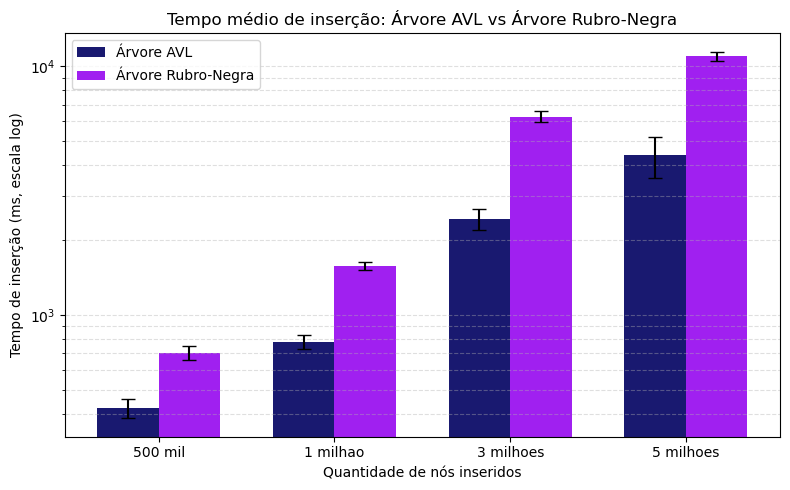

In [8]:
# ---------------------------------------------------------------------------
# 3. GERANDO GRAFICO DE BARRAS AGRUPADAS COM BARRAS DE ERRO (ESCALA LOG)
# ---------------------------------------------------------------------------
x = np.arange(len(volumes))
largura = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    x - largura / 2, avl_media, largura,
    yerr=avl_std, capsize=5,
    label="Árvore AVL", color="#191970",
    edgecolor="none",
)
ax.bar(
    x + largura / 2, rn_media, largura,
    yerr=rn_std, capsize=5,
    label="Árvore Rubro-Negra", color="#A020F0",
    edgecolor="none",
)

ax.set_yscale("log")
ax.set_ylabel("Tempo de inserção (ms, escala log)")
ax.set_xlabel("Quantidade de nós inseridos")
ax.set_title("Tempo médio de inserção: Árvore AVL vs Árvore Rubro-Negra")
ax.set_xticks(x)
ax.set_xticklabels(volumes)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4, which="both")

fig.tight_layout()
#Salavando o gráfico em png 
fig.savefig("grafico_insercao_avl_rn.png", dpi=300)
plt.show()